<center><font size=5><b>Extracting harmonics of $\phi$-dependent data in Gepard - The case of CLAS 2018 XUU</b></font></center>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys 
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [3]:
from scipy.optimize import curve_fit

In [4]:
import gdevel as gd
print(gd.__version__)

0.9.11


In [5]:
import os
import subprocess
branch = subprocess.check_output(['git', '-C', os.path.dirname(gd.__file__),
                                  'branch', '--show-current']).decode('ascii').strip()
revhash = subprocess.check_output(['git', '-C', os.path.dirname(gd.__file__),
                                   'rev-parse', 'HEAD']).decode('ascii').strip()
print('Current git branch is "{}" and revision hash is {}'.format(branch, revhash))

Current git branch is "devel" and revision hash is 6a29f18c7246e4172fd8540814631d1b4fdb0f4a


In [6]:
#sys.path.append('/Users/higuera-admin/Documents/Programs/ldrdgff/gepard/src/gepard/')
sys.path.append('/Users/higuera-admin/Documents/Programs/ldrdgff/gepardDevel/gdevel/src/gdevel')
import mydatafiles
from mydatafiles import ep2epgamma

mydset = gd.data.loaddata(mydatafiles)
mydset.update(gd.data.loaddata(ep2epgamma))

In [7]:
def plotpts(bin1, bin2=None, replica=None):
    """Plot points in bin with errorbars."""
    fig, ax = plt.subplots(1,1, figsize=[6,6])
    ax.errorbar(bin1.phi.values, bin1.val.values, bin1.err.values, color='blue', linestyle='None',
               capsize=3)
    if isinstance(bin2, pd.DataFrame):
        ax.errorbar(bin2.phi.values, bin2.val.values, bin2.err.values, color='red', linestyle='None',
                   capsize=2)
    if isinstance(replica, np.ndarray):
        ax.plot(bin1.phi.values, replica, marker='o', color='red', linestyle='None')
    ax.set_ylim(-0.5, 2.0)
    ax.set_xlim(-np.pi, np.pi)
    fig.savefig('fig')

In [8]:
def plotFT(dfs, cosmax, sinmax):
    """Plot harmonics with with errorbars."""
    CM = cosmax
    SM = sinmax
    fig, ax = plt.subplots(1,1, figsize=[6,6])
    shift = 0
    for df in dfs:
        c = df.val.values[:CM+1]
        delc = df.err.values[:CM+1]
        s = df.val.values[CM+1:CM+SM+1]
        dels = df.err.values[CM+1:CM+SM+1]
        ax.errorbar(np.arange(CM+1)+shift, c, delc, linestyle='None', capsize=3,color='blue')
        ax.errorbar(np.arange(-1,-SM-1,-1)+shift, s, dels, linestyle='None', capsize=3, color='red')
        shift += 0.05
    ax.axhline(linestyle='-.', color='green', linewidth=0.5)
    ax.axvline(linestyle='-.', color='green', linewidth=0.5)
    #ax.legend(loc=4, fontsize=14).draw_frame(1)
    fig.savefig('fig')

In [9]:
def csmax(N):
    """Returns largest cos and sin indices for N points in a bin."""
    cosmax = int((N-1)/2.)
    sinmax = cosmax + ((N-1) % 2)
    assert cosmax + sinmax == N - 1
    return (cosmax, sinmax)

In [10]:
# For check, we compare FT results to simple CLAS-like curve fit
def clasfit(df):
    """Fits A*sin(phi)/(1+B*cos(phi)) to a single xB-Q2-t bin in Pandas dataframe df."""
    # Define your model function
    def model_func(phi, A, B):
        return A * np.sin(phi) / (1 + B * np.cos(phi))
    
    # Assume your DataFrame is named df and has columns: 'phi', 'val', 'err'
    # Example: df = pd.DataFrame({'phi': ..., 'val': ..., 'err': ...})
    
    # Extract numpy arrays from DataFrame
    phi = df['phi'].values
    val = df['val'].values
    err = df['err'].values
    
    # Perform the fit using weights = 1/err^2
    popt, pcov = curve_fit(
        model_func,
        phi,
        val,
        sigma=err,
        absolute_sigma=True,  # use sigma to scale the covariance matrix
        p0=(1.0, 0.0)         # initial guesses for A and B
    )
    
    # Extract fit parameters and uncertainties
    A_fit, B_fit = popt
    A_err, B_err = np.sqrt(np.diag(pcov))
    
    # Print results
    # print(f"A = {A_fit:.6f} ± {A_err:.6f}")
    # print(f"B = {B_fit:.6f} ± {B_err:.6f}")
    return float(A_fit), float(A_err)

In [11]:
def gridplot(k):
    phis = np.linspace(-np.pi, np.pi, 80)  # used for sine curve
    
    fig, axes = plt.subplots(3, 3, figsize=[12, 12])
    axes = axes.flatten()
    
    for i in range(9):
        ki = k + i
        df = binS[ki]
        ax = axes[i]
        
        ax.errorbar(df.phi.values, df.val.values, df.err.values, color='blue',
                    linestyle='None', capsize=3)
        
        amp = df.iloc[0].FTval
        ax.plot(phis, amp * np.sin(phis), color='red', linestyle='solid', lw=2)
        
        ax.set_ylim(-1, 1)
        ax.set_xlim(-np.pi, np.pi)
        ax.set_title(f'binS[{ki}]')
    
    plt.tight_layout()
    fig.savefig('fig_grid')

# Basic extraction of harmonics - Unpolirized cross section XUU (BSS)

In [12]:
ID = 160   # Gepard ID of a dataset

In [13]:
gd.describe_data(mydset[ID])

npt x obs     collab  FTn    id  ref.        
----------------------------------------------
3008 x XUU     CLAS    N/A    160 arxiv.org/pdf/1810.02110
----------------------------------------------
TOTAL = 3008


In [14]:
dfS = mydset[ID].df()[['Q2', 'xB', 'tm', 'in1energy', 'phi', 'val', 'err', 'errstat', 'errsyst']]

In [15]:
if 'err' in dfS.columns:
    dfS.rename(columns={'err': 'errtot'}, inplace=True)   # cannot have two err columns
dfS.rename(columns={'errstat': 'err'}, inplace=True)

In [16]:
# Detect bin breaks based on increasing phi jumps
phi_diff = dfS['phi'].diff().fillna(0)
bin_starts = [0] + list(phi_diff[phi_diff > 2.5].index) + [len(dfS)]

# Initialize bin dictionary and list for bin centers
binS = {}
bin_centers = []

# Loop over bins
for k in range(len(bin_starts) - 1):
    start = bin_starts[k]
    end = bin_starts[k + 1]
    df_bin = dfS.iloc[start:end].copy().reset_index(drop=True)
    
    # Compute central values
    Q2_mean = df_bin['Q2'].mean()
    xB_mean = df_bin['xB'].mean()
    tm_mean = df_bin['tm'].mean()
    
    # Add central values to each row of the bin
    df_bin['Q2_center'] = Q2_mean
    df_bin['xB_center'] = xB_mean
    df_bin['tm_center'] = tm_mean
    
    # Save
    binS[k] = df_bin
    bin_centers.append({'Q2': Q2_mean, 'xB': xB_mean, 'tm': tm_mean})

# Create bins dataframe from collected central values
Sbins = pd.DataFrame(bin_centers)
print('Number of all bins = {}'.format(len(Sbins)))

Number of all bins = 175


In [17]:
binS[127]

,Q2,xB,tm,in1energy,phi,val,errtot,err,errsyst,Q2_center,xB_center,tm_center
0,2.841,0.334,0.264,5.88,3.010693,0.289071,0.022490,0.013370,0.018085,2.85775,0.334583,0.262833
1,2.857,0.334,0.264,5.88,2.752384,0.190125,0.020825,0.015623,0.013769,2.85775,0.334583,0.262833
2,2.861,0.334,0.264,5.88,2.494076,0.154017,0.012465,0.008045,0.009521,2.85775,0.334583,0.262833
3,2.859,0.334,0.264,5.88,2.232276,0.105575,0.008810,0.005760,0.006667,2.85775,0.334583,0.262833
4,2.857,0.334,0.263,5.88,1.970477,0.087878,0.010342,0.006421,0.008107,2.85775,0.334583,0.262833
5,2.857,0.335,0.263,5.88,1.706932,0.068883,0.008870,0.007213,0.005163,2.85775,0.334583,0.262833
6,2.858,0.335,0.262,5.88,1.445133,0.039827,0.005108,0.004339,0.002695,2.85775,0.334583,0.262833
7,2.859,0.335,0.262,5.88,1.181588,0.037129,0.004175,0.003290,0.002569,2.85775,0.334583,0.262833
8,2.860,0.335,0.262,5.88,0.919789,0.026656,0.003285,0.002603,0.002003,2.85775,0.334583,0.262833
9,2.861,0.335,0.262,5.88,0.656244,0.029825,0.008963,0.004490,0.007757,2.85775,0.334583,0.262833


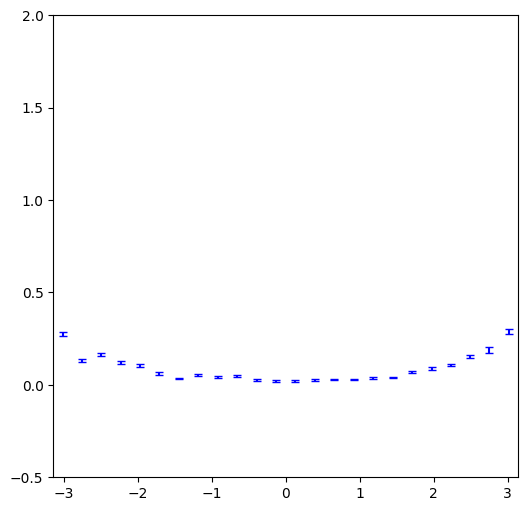

In [18]:
dfphi = binS[127]  # Some example bin
plotpts(dfphi)

In [19]:
cm=2; sm=0

In [20]:
dfFT = gd.data.FTFMC(dfphi, cosmax=cm, sinmax=sm)

In [21]:
dfFT.head(127)

,phi,val,err
0,3.010693,0.089712,0.001431
1,2.752384,-0.091059,0.002372
2,2.494076,0.039563,0.002189
3,2.232276,0.000000,0.000000
4,1.970477,0.000000,0.000000
5,1.706932,0.000000,0.000000
6,1.445133,0.000000,0.000000
7,1.181588,0.000000,0.000000
8,0.919789,0.000000,0.000000
9,0.656244,0.000000,0.000000


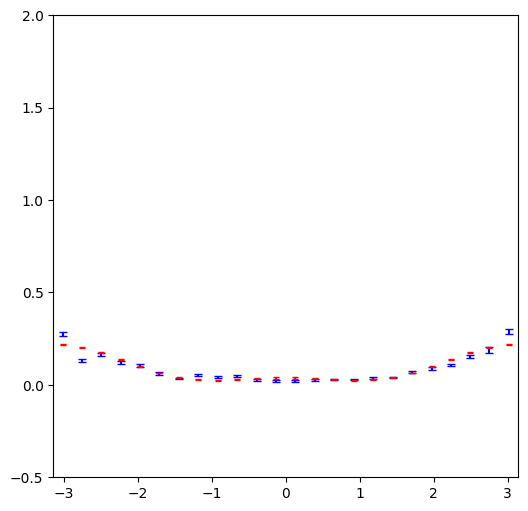

In [22]:
plotpts(dfphi, gd.data.FTFMC(gd.data.FTFMC(dfphi, cosmax=cm, sinmax=sm), inverse=True, cosmax=cm, sinmax=sm))

In [ ]:
'''Sdata = mydset[160]

# This precalculates needed propagators among other things
for pt in Sdata:
    pt.prepare()

# Store normalized BH propagator weights
Swghs = [gd.weight_BH(pt) for pt in Sdata]

# weighted data, NOTE err = everything apart from normalization err !
dfS = pd.DataFrame([
    (
        pt.in1energy,
        pt.Q2,
        pt.xB,
        pt.tm,
        pt.phi,
        w * pt.val,
        w * np.sqrt(pt.err**2 - pt.errnorm**2)  
    )
    for pt, w in zip(Sdata, Swghs)
], columns=('E', 'Q2', 'xB', 'tm', 'phi', 'val', 'err'))

# Detect bin breaks based on increasing phi jumps
phi_diff = dfS['phi'].diff().fillna(0)
bin_starts = [0] + list(phi_diff[phi_diff > 2.5].index) + [len(dfS)]

# Initialize bin dictionary and list for bin centers
binS = {}
bin_centers = []

# Loop over bins
for k in range(len(bin_starts) - 1):
    start = bin_starts[k]
    end = bin_starts[k + 1]
    df_bin = dfS.iloc[start:end].copy().reset_index(drop=True)
    
    # Compute central values
    Q2_mean = df_bin['Q2'].mean()
    xB_mean = df_bin['xB'].mean()
    tm_mean = df_bin['tm'].mean()
    
    # Add central values to each row of the bin
    df_bin['Q2_center'] = Q2_mean
    df_bin['xB_center'] = xB_mean
    df_bin['tm_center'] = tm_mean
    
    # Save
    binS[k] = df_bin
    bin_centers.append({'Q2': Q2_mean, 'xB': xB_mean, 'tm': tm_mean})

# Create bins dataframe from collected central values
Sbins = pd.DataFrame(bin_centers)
print('Number of all bins = {}'.format(len(Sbins)))'''

Number of all bins = 175


In [24]:
nc, ns = gd.data.FTanalyse(binS)

Highest extractable cos harmonic = 1.109 +- 0.752
Highest extractable sin harmonic = 0.623 +- 0.753



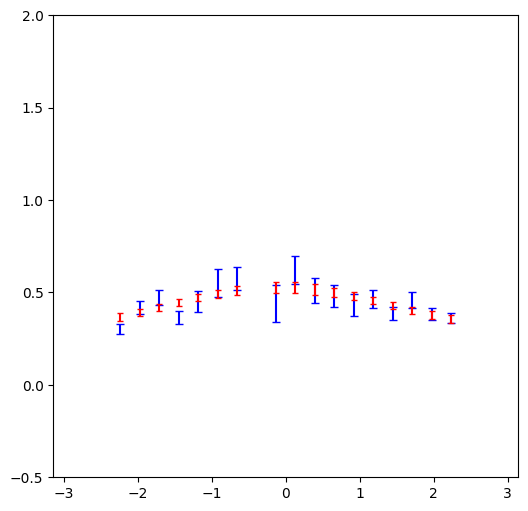

In [25]:
plotpts(binS[4], gd.data.FTFMC(gd.data.FTFMC(binS[4], cosmax=nc, sinmax=ns), inverse=True, cosmax=nc, sinmax=ns))

In [26]:
nc = 2
ns = 0

for k in Sbins.index:
    bn = binS[k]
    dfFT = gd.data.FTFMC(bn, nsamples=3000, cosmax=nc, sinmax=ns)
    if len(dfFT) >= 2:  # at least 2 armonics
        for typ in ('val', 'err'):
            bn[f'FT{typ}'] = pd.Series(dfFT[typ].values[:len(bn)], index=bn.index)
    else:
        print(f"Bin {k} skipped: not enough data for cos1.")

def c0(bin):
    return bin[['E', 'Q2', 'xB', 'tm', 'FTval', 'FTerr']].iloc[0]

def c1(bin):
    #if len(bin) < 2:
    #    return None
    return bin[['E', 'Q2', 'xB', 'tm', 'FTval', 'FTerr']].iloc[1]

def c2(bin):
    #if len(bin) < 3:
    #    return None
    return bin[['E', 'Q2', 'xB', 'tm', 'FTval', 'FTerr']].iloc[2]

FTc0 = pd.DataFrame([c0(binS[k]) for k in Sbins.index]).reset_index(drop=True)
FTc0['FTn'] = 0

FTc1 = pd.DataFrame([c1(binS[k]) for k in Sbins.index]).reset_index(drop=True)
FTc1['FTn'] = 1

FTc2 = pd.DataFrame([c2(binS[k]) for k in Sbins.index]).reset_index(drop=True)
FTc2['FTn'] = 2

In [27]:
print(FTc0[['xB', 'Q2', 'tm', 'FTn', 'FTval', 'FTerr']].to_string(index=False))

   xB    Q2    tm  FTn     FTval      FTerr
0.125 1.129 0.108    0  3.373865   0.269163
0.124 1.128 0.153    0  2.058128   0.116645
0.125 1.129 0.203    0  1.274501   0.091588
0.125 1.129 0.263    0  0.803685   0.029099
0.125 1.130 0.340    0  0.423828   0.016859
0.125 1.126 0.451    0  0.226428   0.006420
0.125 1.125 0.615    0  0.100379   0.003357
0.126 1.130 0.859    0  0.030453   0.002735
0.126 1.127 1.398    0  0.010852   0.005648
0.155 1.302 0.108    0  1.966746   0.067061
0.154 1.299 0.153    0  1.157266   0.040317
0.154 1.300 0.203    0  0.689559   0.025337
0.154 1.301 0.262    0  0.476411   0.020402
0.154 1.301 0.341    0  0.280624   0.011891
0.155 1.301 0.451    0  0.136873   0.007627
0.155 1.303 0.603    0  0.057354   0.004484
0.154 1.295 0.895    0 -5.761250 303.004096
0.155 1.302 1.392    0  0.013811   0.007610
0.155 1.423 0.108    0  2.161798   0.175812
0.155 1.424 0.153    0  1.452914   0.086396
0.155 1.425 0.203    0  0.786233   0.057578
0.155 1.424 0.263    0  0.523174

In [28]:
print(FTc1[['xB', 'Q2', 'tm', 'FTn', 'FTval', 'FTerr']].to_string(index=False))

   xB    Q2    tm  FTn     FTval       FTerr
0.124 1.128 0.108    1  0.987860    0.454262
0.124 1.129 0.153    1  0.191192    0.199117
0.125 1.129 0.203    1  0.275272    0.143541
0.125 1.129 0.262    1  0.203300    0.048638
0.125 1.130 0.340    1  0.107847    0.023821
0.125 1.130 0.446    1  0.060481    0.009900
0.126 1.131 0.602    1  0.031172    0.005005
0.126 1.130 0.860    1  0.007438    0.004884
0.126 1.128 1.390    1  0.010360    0.009078
0.154 1.298 0.109    1  0.118131    0.093574
0.154 1.300 0.153    1  0.135447    0.066410
0.154 1.301 0.203    1  0.136658    0.039878
0.154 1.301 0.262    1  0.025201    0.028558
0.154 1.302 0.340    1  0.063144    0.020171
0.155 1.302 0.447    1  0.036146    0.009577
0.155 1.302 0.604    1  0.018277    0.005907
0.155 1.303 0.860    1 -8.492533  445.703765
0.155 1.302 1.386    1  0.016689    0.012012
0.155 1.424 0.108    1  0.476947    0.289765
0.155 1.425 0.153    1  0.083918    0.142556
0.155 1.425 0.203    1  0.150344    0.091284
0.155 1.42

In [29]:
pd.set_option('display.float_format', '{:.6f}'.format)
print(FTc2[['xB', 'Q2', 'tm', 'FTn', 'FTval', 'FTerr']].to_string(index=False))

      xB       Q2       tm  FTn     FTval      FTerr
0.124000 1.128000 0.108000    2 -0.188940   0.292925
0.124000 1.129000 0.152000    2  0.188095   0.151537
0.125000 1.129000 0.203000    2  0.042305   0.108380
0.125000 1.130000 0.261000    2  0.012904   0.045129
0.125000 1.130000 0.340000    2 -0.000102   0.027797
0.125000 1.130000 0.446000    2  0.017876   0.010863
0.125000 1.131000 0.603000    2  0.003476   0.005531
0.126000 1.130000 0.862000    2 -0.002832   0.004035
0.126000 1.130000 1.382000    2  0.002390   0.004281
0.154000 1.299000 0.109000    2  0.178820   0.110908
0.154000 1.301000 0.153000    2 -0.055527   0.064541
0.154000 1.301000 0.203000    2  0.032651   0.042143
0.154000 1.302000 0.262000    2  0.075944   0.033434
0.154000 1.302000 0.340000    2  0.007453   0.020966
0.154000 1.302000 0.447000    2  0.000191   0.013239
0.155000 1.303000 0.604000    2 -0.010514   0.007666
0.155000 1.303000 0.863000    2 -2.572890 135.324468
0.155000 1.303000 1.382000    2  0.005603   0.

In [30]:
def csfit_plot(df, show_fit=True):
    """Ajusta C0 + C1*cos(phi) + C2*cos(2phi) a sección eficaz y grafica."""
    
    def model_func(phi, C0, C1, C2):
        return C0 + C1 * np.cos(phi) + C2 * np.cos(2*phi)
    
    phi = df['phi'].values
    val = df['val'].values
    err = df['err'].values
    
    # Fit
    popt, pcov = curve_fit(
        model_func,
        phi,
        val,
        sigma=err,
        absolute_sigma=True,
        p0=(1.0, 1.0, 0.1)
    )
    C0, C1, C2 = popt
    dC0, dC1, dC2 = np.sqrt(np.diag(pcov))

    # Result
    print(f"C0 = {C0:.3f} ± {dC0:.3f}")
    print(f"C1 = {C1:.3f} ± {dC1:.3f}")
    print(f"C2 = {C2:.3f} ± {dC2:.3f}")

    # Plot
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.errorbar(phi, val, err, fmt='o', capsize=3, label='Data', color='black')
    
    if show_fit:
        phi_fit = np.linspace(-np.pi, np.pi, 300)
        y_fit = model_func(phi_fit, C0, C1, C2)
        ax.plot(phi_fit, y_fit, label=r'$C_0 + C_1 \cos\phi + C_2 \cos2\phi$', color='red')

    ax.set_xlabel(r'$\phi$ [rad]')
    ax.set_ylabel('Cross section (arbitrary units)')
    ax.set_title('Cross section fit per bin')
    ax.grid(False)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return C0, dC0, C1, dC1, C2, dC2

C0 = 0.785 ± 0.028
C1 = 0.211 ± 0.046
C2 = 0.004 ± 0.041


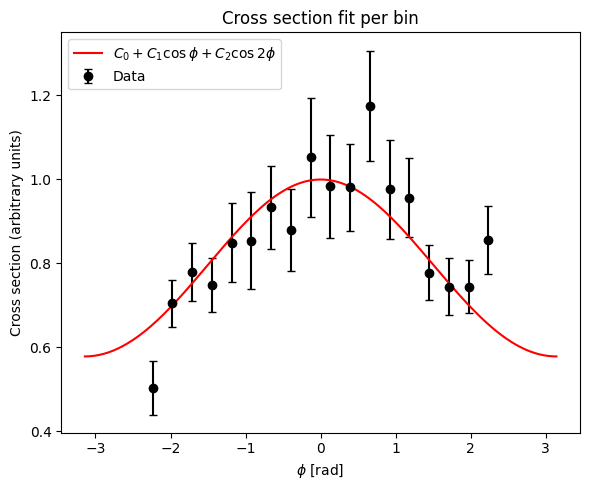

(np.float64(0.7852063619917997),
 np.float64(0.02823484496928701),
 np.float64(0.2108426185222163),
 np.float64(0.04592185491634706),
 np.float64(0.003564929070988321),
 np.float64(0.04136672745841454))

In [31]:
csfit_plot(binS[3])

## Treatment with cos-phi uncertainty enhancement

In [32]:
np.sqrt(np.sum([err**2 for err in [5.7, 5.3, 5, 3.5, 2.2, 1.6, 1]]))

np.float64(10.306793875885944)

In [33]:
def c0(bin):
    """Zeroth cosine harmonic of bin with total error."""
    # correlated syst error in %
    corrD = np.sqrt(np.sum([err**2 for err in [5.7, 5.3, 5, 3.5, 2.2, 1.6, 1]]))
    # correlated syts error
    syst = abs(bin['FTval'].iloc[0] * corrD * 0.01)
    aux = bin[['Q2', 'xB', 'tm', 'FTval', 'FTerr']].iloc[0]   
    return pd.concat([aux, pd.Series([syst], index=['syst'])])

def c1(bin, enh=1.):
    """First cosine harmonic of bin with total error.
    
    enh - enhancement of phi-modulated sources of syst err
    """
    corrD = np.sqrt(np.sum([err**2 for err in [enh*5.7, enh*5.3, 5, 
                                               3.5, 2.2, 1.6, 1]]))
    # correlated syts error
    syst = abs(bin['FTval'].iloc[1] * corrD * 0.01)
    aux = bin[['Q2', 'xB', 'tm', 'FTval', 'FTerr']].iloc[1]   
    return pd.concat([aux, pd.Series([syst], index=['syst'])])

def c2(bin, enh=1.):
    """Second cosine harmonic of bin with total error.
    
    enh - enhancement of phi-modulated sources of syst err
    """
    # Enhancement applies only to phi-modulated systematics
    # Safe enhancement
    enh = abs(enh) if np.isfinite(enh) else 1.  # replace invalid values with 1
    
    # Compute total correlated error in %
    corrD = np.sqrt(np.sum([(enh * 5.7)**2, (enh * 5.3)**2, 5**2, 3.5**2, 2.2**2, 1.6**2, 1**2]))
    
    syst = abs(bin['FTval'].iloc[2] * corrD * 0.01)
    aux = bin[['Q2', 'xB', 'tm', 'FTval', 'FTerr']].iloc[2]
    return pd.concat([aux, pd.Series([syst], index=['syst'])])


In [34]:
FTc0 = pd.DataFrame([c0(binS[k]) for k in Sbins.index]).reset_index(drop=True)
FTc0['FTn'] = 0
FTc1 = pd.DataFrame([c1(binS[k], enh=1.) for k in Sbins.index]).reset_index(drop=True)
FTc2 = pd.DataFrame([c2(binS[k], enh=1.) for k in Sbins.index]).reset_index(drop=True)

In [35]:
# enhancement ratios by bins
c0overc1 = FTc0['FTval'].values / FTc1['FTval'].values; c0overc1
c0overc2 = FTc0['FTval'].values / FTc2['FTval'].values; c0overc2

array([-1.78567745e+01,  1.09419773e+01,  3.01265877e+01,  6.22831317e+01,
       -4.16190316e+03,  1.26662704e+01,  2.88786867e+01, -1.07529709e+01,
        4.54040875e+00,  1.09984825e+01, -2.08413980e+01,  2.11188503e+01,
        6.27320752e+00,  3.76546319e+01,  7.15223460e+02, -5.45517670e+00,
        2.23921355e+00,  2.46500367e+00, -1.02125122e+02,  9.39069272e+00,
       -3.20814508e+01,  2.04736415e+01,  1.12351402e+02, -3.23333322e+01,
       -7.41872418e+01, -1.09812932e+01,  4.72874666e+00, -1.52217657e+01,
       -2.71367582e+01,  8.28969698e+01,  1.50143657e+01, -1.91470235e+01,
        4.37724253e+00, -6.85051165e+00,  5.28837483e+00,  1.87479860e+00,
       -2.45694680e+02, -8.99938299e+00,  2.66266169e+01, -4.01348535e+02,
        1.32889814e+01,  1.52677684e+01,  1.77707260e+01, -4.93877645e+00,
        7.91660897e+00, -1.85504887e+01, -7.15825621e+00, -1.66079811e+01,
       -1.15172327e+01, -1.52895703e+01,  9.48541736e+00, -7.20134913e+00,
        1.64184795e+00, -

In [36]:
FTc1 = pd.DataFrame([c1(binS[k], enh=c0overc1[k]) for k in Sbins.index]).reset_index(drop=True)
FTc1['FTn'] = 1
FTc2 = pd.DataFrame([c2(binS[k], enh=c0overc2[k]) for k in Sbins.index]).reset_index(drop=True)
FTc2['FTn'] = 2

In [37]:
# Apply cuts: |FTerr| < 100 and -t/Q² < 0.25
# Clean FTc1
print("Before filter:", len(FTc1))
FTc1 = FTc1[(FTc1['FTerr'].abs() < 10) & (FTc1['tm'] / FTc1['Q2'] < 0.25)].reset_index(drop=True)
print("After filter:", len(FTc1))

print(FTc1[['Q2', 'xB', 'tm', 'FTval', 'FTerr', 'syst', 'FTn']].to_string(index=False))

Before filter: 175
After filter: 108
      Q2       xB       tm     FTval    FTerr     syst  FTn
1.128000 0.124000 0.108000  0.987860 0.454262 0.270948    1
1.129000 0.124000 0.153000  0.191192 0.199117 0.160711    1
1.129000 0.125000 0.203000  0.275272 0.143541 0.100927    1
1.129000 0.125000 0.262000  0.203300 0.048638 0.064044    1
1.298000 0.154000 0.109000  0.118131 0.093574 0.153286    1
1.300000 0.154000 0.153000  0.135447 0.066410 0.090537    1
1.301000 0.154000 0.203000  0.136658 0.039878 0.054459    1
1.301000 0.154000 0.262000  0.025201 0.028558 0.037120    1
1.424000 0.155000 0.108000  0.476947 0.289765 0.171318    1
1.425000 0.155000 0.153000  0.083918 0.142556 0.113227    1
1.425000 0.155000 0.203000  0.150344 0.091284 0.062032    1
1.425000 0.155000 0.262000  0.022436 0.031886 0.040748    1
1.426000 0.155000 0.340000  0.015499 0.126184 0.024854    1
1.483000 0.184000 0.109000  0.091361 0.045678 0.084844    1
1.485000 0.184000 0.154000  0.135468 0.029079 0.053138    1
1.4

In [38]:
# Apply cuts: |FTerr| < 100 and -t/Q² < 0.25
# Clean FTc2
print("Before filter:", len(FTc2))
FTc2 = FTc2[(FTc2['FTerr'].abs() < 10) & (FTc2['tm'] / FTc2['Q2'] < 0.25)].reset_index(drop=True)
print("After filter:", len(FTc2))

print(FTc2[['Q2', 'xB', 'tm', 'FTval', 'FTerr', 'syst', 'FTn']].to_string(index=False))

Before filter: 175
After filter: 110
      Q2       xB       tm     FTval    FTerr     syst  FTn
1.128000 0.124000 0.108000 -0.188940 0.292925 0.262909    2
1.129000 0.124000 0.152000  0.188095 0.151537 0.160694    2
1.129000 0.125000 0.203000  0.042305 0.108380 0.099240    2
1.130000 0.125000 0.261000  0.012904 0.045129 0.062559    2
1.299000 0.154000 0.109000  0.178820 0.110908 0.153554    2
1.301000 0.154000 0.153000 -0.055527 0.064541 0.090152    2
1.301000 0.154000 0.203000  0.032651 0.042143 0.053716    2
1.302000 0.154000 0.262000  0.075944 0.033434 0.037434    2
1.424000 0.155000 0.108000 -0.021168 0.227745 0.168266    2
1.425000 0.155000 0.153000  0.154719 0.104753 0.113567    2
1.426000 0.155000 0.203000 -0.024507 0.076274 0.061217    2
1.426000 0.155000 0.262000  0.025554 0.030763 0.040757    2
1.426000 0.155000 0.340000  0.002840 0.074018 0.024833    2
1.484000 0.184000 0.109000 -0.071423 0.044723 0.084757    2
1.486000 0.184000 0.154000 -0.024783 0.031448 0.052371    2
1.4

In [39]:
# Apply cuts: |FTerr| < 100 and -t/Q² < 0.25
# Clean FTc0
print("Before filter:", len(FTc0))
FTc0 = FTc0[(FTc0['FTerr'].abs() < 10) & (FTc0['tm'] / FTc0['Q2'] < 0.25)].reset_index(drop=True)
print("After filter:", len(FTc0))

# Print clean table with non-exponential numbers
print(FTc0[['Q2', 'xB', 'tm', 'FTval', 'FTerr', 'syst', 'FTn']].to_string(index=False))


Before filter: 175
After filter: 109
      Q2       xB       tm     FTval    FTerr     syst  FTn
1.129000 0.125000 0.108000  3.373865 0.269163 0.347737    0
1.128000 0.124000 0.153000  2.058128 0.116645 0.212127    0
1.129000 0.125000 0.203000  1.274501 0.091588 0.131360    0
1.129000 0.125000 0.263000  0.803685 0.029099 0.082834    0
1.302000 0.155000 0.108000  1.966746 0.067061 0.202708    0
1.299000 0.154000 0.153000  1.157266 0.040317 0.119277    0
1.300000 0.154000 0.203000  0.689559 0.025337 0.071071    0
1.301000 0.154000 0.262000  0.476411 0.020402 0.049103    0
1.423000 0.155000 0.108000  2.161798 0.175812 0.222812    0
1.424000 0.155000 0.153000  1.452914 0.086396 0.149749    0
1.425000 0.155000 0.203000  0.786233 0.057578 0.081035    0
1.424000 0.155000 0.263000  0.523174 0.018587 0.053922    0
1.426000 0.155000 0.340000  0.319039 0.074062 0.032883    0
1.484000 0.184000 0.109000  1.087185 0.031243 0.112054    0
1.487000 0.186000 0.152000  0.672519 0.019074 0.069315    0
1.4

# Basic extraction of harmonics - Polirized cross section XLU (BSD)

In [13]:
ID = 163

In [14]:
gd.describe_data(mydset[ID])

npt x obs     collab  FTn    id  ref.        
----------------------------------------------
3008 x XLU     CLAS    N/A    163 arxiv.org/pdf/1810.02110
----------------------------------------------
TOTAL = 3008


In [15]:
dfS = mydset[ID].df()[['Q2', 'xB', 'tm', 'in1energy', 'phi', 'val', 'err', 'errstat', 'errsyst']]

In [16]:
if 'err' in dfS.columns:
    dfS.rename(columns={'err': 'errtot'}, inplace=True)   # cannot have two err columns
dfS.rename(columns={'errstat': 'err'}, inplace=True)

In [17]:
# Detect bin breaks based on increasing phi jumps
phi_diff = dfS['phi'].diff().fillna(0)
bin_starts = [0] + list(phi_diff[phi_diff > 2.5].index) + [len(dfS)]

# Initialize bin dictionary and list for bin centers
binS = {}
bin_centers = []

# Loop over bins
for k in range(len(bin_starts) - 1):
    start = bin_starts[k]
    end = bin_starts[k + 1]
    df_bin = dfS.iloc[start:end].copy().reset_index(drop=True)
    
    # Compute central values
    Q2_mean = df_bin['Q2'].mean()
    xB_mean = df_bin['xB'].mean()
    tm_mean = df_bin['tm'].mean()
    
    # Add central values to each row of the bin
    df_bin['Q2_center'] = Q2_mean
    df_bin['xB_center'] = xB_mean
    df_bin['tm_center'] = tm_mean
    
    # Save
    binS[k] = df_bin
    bin_centers.append({'Q2': Q2_mean, 'xB': xB_mean, 'tm': tm_mean})

# Create bins dataframe from collected central values
Sbins = pd.DataFrame(bin_centers)
print('Number of all bins = {}'.format(len(Sbins)))

Number of all bins = 175


In [18]:
binS[127]

,Q2,xB,tm,in1energy,phi,val,errtot,err,errsyst,Q2_center,xB_center,tm_center
0,2.841,0.334,0.264,5.88,3.010693,-0.007884,0.012079,0.010036,0.006722,2.85775,0.334583,0.262833
1,2.857,0.334,0.264,5.88,2.752384,0.006114,0.012510,0.011569,0.004760,2.85775,0.334583,0.262833
2,2.861,0.334,0.264,5.88,2.494076,0.039398,0.006774,0.006214,0.002697,2.85775,0.334583,0.262833
3,2.859,0.334,0.264,5.88,2.232276,0.028209,0.005074,0.004520,0.002307,2.85775,0.334583,0.262833
4,2.857,0.334,0.263,5.88,1.970477,0.022621,0.005451,0.005056,0.002037,2.85775,0.334583,0.262833
5,2.857,0.335,0.263,5.88,1.706932,0.010934,0.009056,0.005774,0.006977,2.85775,0.334583,0.262833
6,2.858,0.335,0.262,5.88,1.445133,0.018992,0.004036,0.003803,0.001349,2.85775,0.334583,0.262833
7,2.859,0.335,0.262,5.88,1.181588,0.008475,0.002750,0.002682,0.000610,2.85775,0.334583,0.262833
8,2.860,0.335,0.262,5.88,0.919789,0.002573,0.002373,0.002166,0.000968,2.85775,0.334583,0.262833
9,2.861,0.335,0.262,5.88,0.656244,0.012644,0.008465,0.003934,0.007496,2.85775,0.334583,0.262833


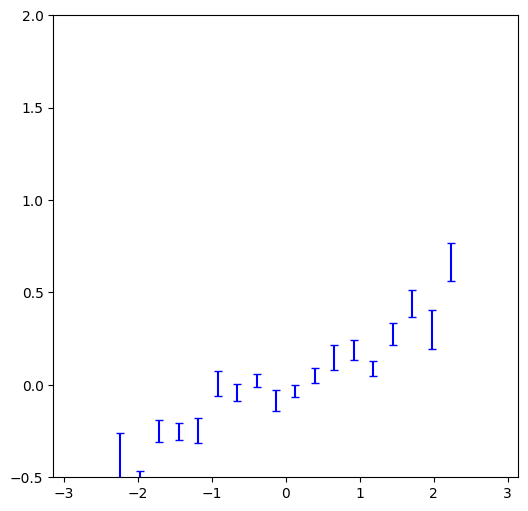

In [19]:
dfphi = binS[10]  # Some example bin
plotpts(dfphi)

There is a Gepard function `FTFMC` that will, for given bin, by default extract all harmonics using discrete Fourier transform and Monte Carlo uncertainty propagation.

Sometimes (first observed for 2022 CLAS A_LU) for observables
such as X_LU or A_LU which are known to vanish at phi = 0 degrees, one needs to enforce this by removing cos(phi)
harmonics from the analysis (especially troublesome is cos(0*phi)). This is done by specifying cosmax=-1 to FTFMC. In
this case, one can also limit the number of sine harmonics by sinmax.

In [20]:
cm=-1; sm=2

In [21]:
dfFT = gd.data.FTFMC(dfphi, cosmax=cm, sinmax=sm)

In [22]:
dfFT.head(5)

,phi,val,err
0,2.235767,0.337807,0.026212
1,1.972222,-0.180650,0.031399
2,1.710423,0.000000,0.000000
3,1.446878,0.000000,0.000000
4,1.183333,0.000000,0.000000


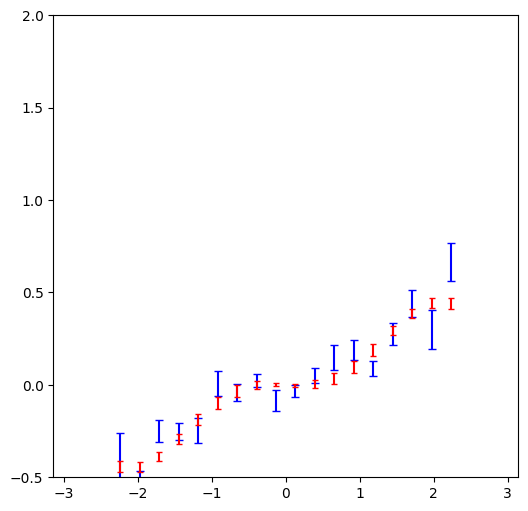

In [23]:
plotpts(dfphi, gd.data.FTFMC(gd.data.FTFMC(dfphi, cosmax=cm, sinmax=sm), inverse=True, cosmax=cm, sinmax=sm))

In [24]:
nc, ns = gd.data.FTanalyse(binS)

Highest extractable cos harmonic = 0.491 +- 0.683
Highest extractable sin harmonic = 1.577 +- 0.679



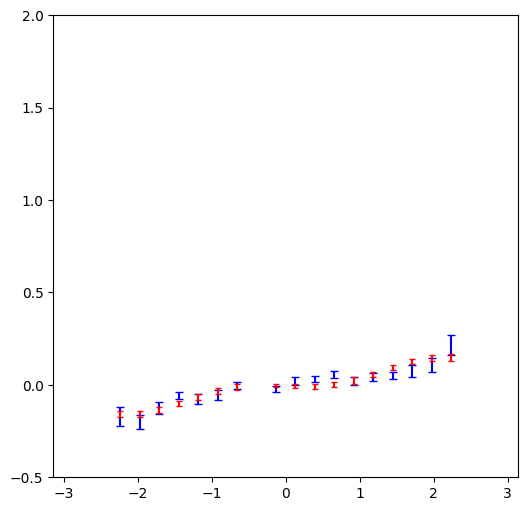

In [25]:
plotpts(binS[4], gd.data.FTFMC(gd.data.FTFMC(binS[4], cosmax=nc, sinmax=ns), inverse=True, cosmax=nc, sinmax=ns))

For final harmonic analysis we increase the number of Monte Carlo samples and store the results in two new dataframe columns:

In [26]:
for k in range(len(Sbins)):
    dfFT = gd.data.FTFMC(binS[k], cosmax=cm, sinmax=sm, nsamples = 3000)
    binS[k]['FTval'] = pd.Series(dfFT['val'].values, index=binS[k].index)
    binS[k]['FTerr'] = pd.Series(dfFT['err'].values, index=binS[k].index)

In [27]:
binS[4].columns

Index(['Q2', 'xB', 'tm', 'in1energy', 'phi', 'val', 'errtot', 'err', 'errsyst',
       'Q2_center', 'xB_center', 'tm_center', 'FTval', 'FTerr'],
      dtype='object')

In [28]:
def s1(bin):
    """Take just first sine harmonic of bin with error."""
    s1ind = cm + 1 # index of first sine harmonic
    return bin[['Q2_center', 'xB_center', 'tm_center', 'FTval', 'FTerr']].iloc[s1ind]

'''def s2(bin):
    s2ind = cm + 2
    return bin[['Q2_center', 'xB_center', 'tm_center', 'FTval', 'FTerr']].iloc[s2ind]'''

"def s2(bin):\n    s2ind = cm + 2\n    return bin[['Q2_center', 'xB_center', 'tm_center', 'FTval', 'FTerr']].iloc[s2ind]"

We unite all bins, taking value and uncertainty of just calculated first sine harmonic (FTval and FTerr), and
we also calculate average and maximal systematic error for given bin. One can than choose which of the two
to take as the proper systematic error of the harmonic (more sophisticated treatment could be implemented here by the person who understands systematics better).

In [29]:
FTs1 = pd.DataFrame([pd.concat([s1(binS[k]),
                                pd.Series([binS[k]['errsyst'].mean(),
                                                     binS[k]['errsyst'].max()], index=['avgsyst', 'maxsyst'])])
                     for k in Sbins.index]).reset_index(drop=True)

'''FTs2 = pd.DataFrame([pd.concat([s2(binS[k]),
                                pd.Series([binS[k]['errsyst'].mean(),
                                           binS[k]['errsyst'].max()],
                                          index=['avgsyst', 'maxsyst'])])
                     for k in Sbins.index]).reset_index(drop=True)'''

"FTs2 = pd.DataFrame([pd.concat([s2(binS[k]),\n                                pd.Series([binS[k]['errsyst'].mean(),\n                                           binS[k]['errsyst'].max()],\n                                          index=['avgsyst', 'maxsyst'])])\n                     for k in Sbins.index]).reset_index(drop=True)"

This (after maybe some reduction of significant digits) can now be saved into the new Gepard datafile with appropriate preamble:

In [30]:
FTs1['FTval'] = FTs1['FTval'].map(lambda x: '%.3f' % x)
FTs1['FTerr'] = FTs1['FTerr'].map(lambda x: '%.3f' % x)
FTs1['FTerrsyst'] = FTs1['avgsyst'].map(lambda x: '%.3f' % x)   # choose maxsyst to be conservative

'''FTs2['FTval'] = FTs2['FTval'].map(lambda x: '%.3f' % x)
FTs2['FTerr'] = FTs2['FTerr'].map(lambda x: '%.3f' % x)
FTs2['FTerrsyst'] = FTs2['avgsyst'].map(lambda x: '%.3f' % x) '''

"FTs2['FTval'] = FTs2['FTval'].map(lambda x: '%.3f' % x)\nFTs2['FTerr'] = FTs2['FTerr'].map(lambda x: '%.3f' % x)\nFTs2['FTerrsyst'] = FTs2['avgsyst'].map(lambda x: '%.3f' % x) "

In [31]:
print(FTs1[['Q2_center', 'xB_center', 'tm_center', 'FTval', 'FTerr', 'FTerrsyst']].to_string(index=False))

 Q2_center  xB_center  tm_center  FTval FTerr FTerrsyst
  1.128625   0.124125   0.108000  0.468 0.076     0.105
  1.129250   0.124250   0.152250  0.480 0.041     0.055
  1.129600   0.125000   0.203000  0.249 0.029     0.028
  1.130000   0.125000   0.261333  0.212 0.023     0.034
  1.130529   0.125000   0.340000  0.113 0.011     0.016
  1.130300   0.125000   0.446500  0.047 0.008     0.009
  1.130800   0.125100   0.604100  0.015 0.004     0.005
  1.131143   0.125286   0.862857  0.001 0.002     0.003
  1.130687   0.125375   1.382000  0.001 0.003     0.001
  1.300368   0.154105   0.108211  0.610 0.046     0.075
  1.300889   0.154000   0.152667  0.340 0.025     0.038
  1.301444   0.154000   0.203000  0.171 0.017     0.023
  1.301765   0.154000   0.261588  0.134 0.013     0.021
  1.302125   0.154000   0.340125  0.085 0.009     0.010
  1.302400   0.154200   0.447000  0.034 0.006     0.010
  1.302895   0.154421   0.603632  0.014 0.003     0.005
  1.302000   0.154875   0.867813  0.001 0.004   

In [32]:
FTs1['FTerr'] = pd.to_numeric(FTs1['FTerr'], errors='coerce')
FTs1['tm_center'] = pd.to_numeric(FTs1['tm_center'], errors='coerce')
FTs1['Q2_center'] = pd.to_numeric(FTs1['Q2_center'], errors='coerce')

In [33]:
# Apply cuts: |FTerr| < 10 and -t/Q² < 0.25
# Clean FTs1
print("Before filter:", len(FTs1))
FTs1 = FTs1[(FTs1['FTerr'].abs() < 1) & (FTs1['tm_center'] / FTs1['Q2_center'] < 0.25)].reset_index(drop=True)
print("After filter:", len(FTs1))

# Print clean table with non-exponential numbers
print(FTs1[['Q2_center', 'xB_center', 'tm_center', 'FTval', 'FTerr', 'FTerrsyst']].to_string(index=False))

Before filter: 175
After filter: 112
 Q2_center  xB_center  tm_center  FTval  FTerr FTerrsyst
  1.128625   0.124125   0.108000  0.468  0.076     0.105
  1.129250   0.124250   0.152250  0.480  0.041     0.055
  1.129600   0.125000   0.203000  0.249  0.029     0.028
  1.130000   0.125000   0.261333  0.212  0.023     0.034
  1.300368   0.154105   0.108211  0.610  0.046     0.075
  1.300889   0.154000   0.152667  0.340  0.025     0.038
  1.301444   0.154000   0.203000  0.171  0.017     0.023
  1.301765   0.154000   0.261588  0.134  0.013     0.021
  1.424500   0.155000   0.108000  0.431  0.041     0.062
  1.425500   0.155000   0.152500  0.280  0.023     0.030
  1.425750   0.155000   0.203000  0.148  0.017     0.021
  1.426111   0.155000   0.261556  0.170  0.014     0.015
  1.426556   0.155000   0.340000  0.080  0.008     0.106
  1.485864   0.184000   0.108500  0.356  0.024     0.067
  1.487091   0.184182   0.153091  0.193  0.015     0.030
  1.487400   0.184000   0.203200  0.179  0.012     

In [ ]:
'''FTs2['FTerr'] = pd.to_numeric(FTs2['FTerr'], errors='coerce')
FTs2['tm_center'] = pd.to_numeric(FTs2['tm_center'], errors='coerce')
FTs2['Q2_center'] = pd.to_numeric(FTs2['Q2_center'], errors='coerce')'''

In [ ]:
'''# Apply cuts: |FTerr| < 10 and -t/Q² < 0.25
# Clean FTs1
print("Before filter:", len(FTs2))
FTs2 = FTs2[(FTs2['FTerr'].abs() < 100) & (FTs2['tm_center'] / FTs2['Q2_center'] < 0.25)].reset_index(drop=True)
print("After filter:", len(FTs2))

# Print clean table with non-exponential numbers
print(FTs2[['Q2_center', 'xB_center', 'tm_center', 'FTval', 'FTerr', 'FTerrsyst']].to_string(index=False))'''

Before filter: 175
After filter: 112
 Q2_center  xB_center  tm_center  FTval  FTerr FTerrsyst
  1.128625   0.124125   0.108000 -0.056  0.085     0.105
  1.129250   0.124250   0.152250 -0.253  0.045     0.055
  1.129600   0.125000   0.203000 -0.085  0.033     0.028
  1.130000   0.125000   0.261333 -0.102  0.030     0.034
  1.300368   0.154105   0.108211 -0.397  0.061     0.075
  1.300889   0.154000   0.152667 -0.184  0.028     0.038
  1.301444   0.154000   0.203000 -0.075  0.019     0.023
  1.301765   0.154000   0.261588 -0.078  0.015     0.021
  1.424500   0.155000   0.108000 -0.138  0.046     0.062
  1.425500   0.155000   0.152500 -0.093  0.026     0.030
  1.425750   0.155000   0.203000 -0.059  0.018     0.021
  1.426111   0.155000   0.261556 -0.108  0.017     0.015
  1.426556   0.155000   0.340000 -0.046  0.009     0.106
  1.485864   0.184000   0.108500 -0.138  0.027     0.067
  1.487091   0.184182   0.153091 -0.083  0.019     0.030
  1.487400   0.184000   0.203200 -0.135  0.014     

Such procedure was followed to create the Gepard datafile ID=164 (not public yet)

# Visual check

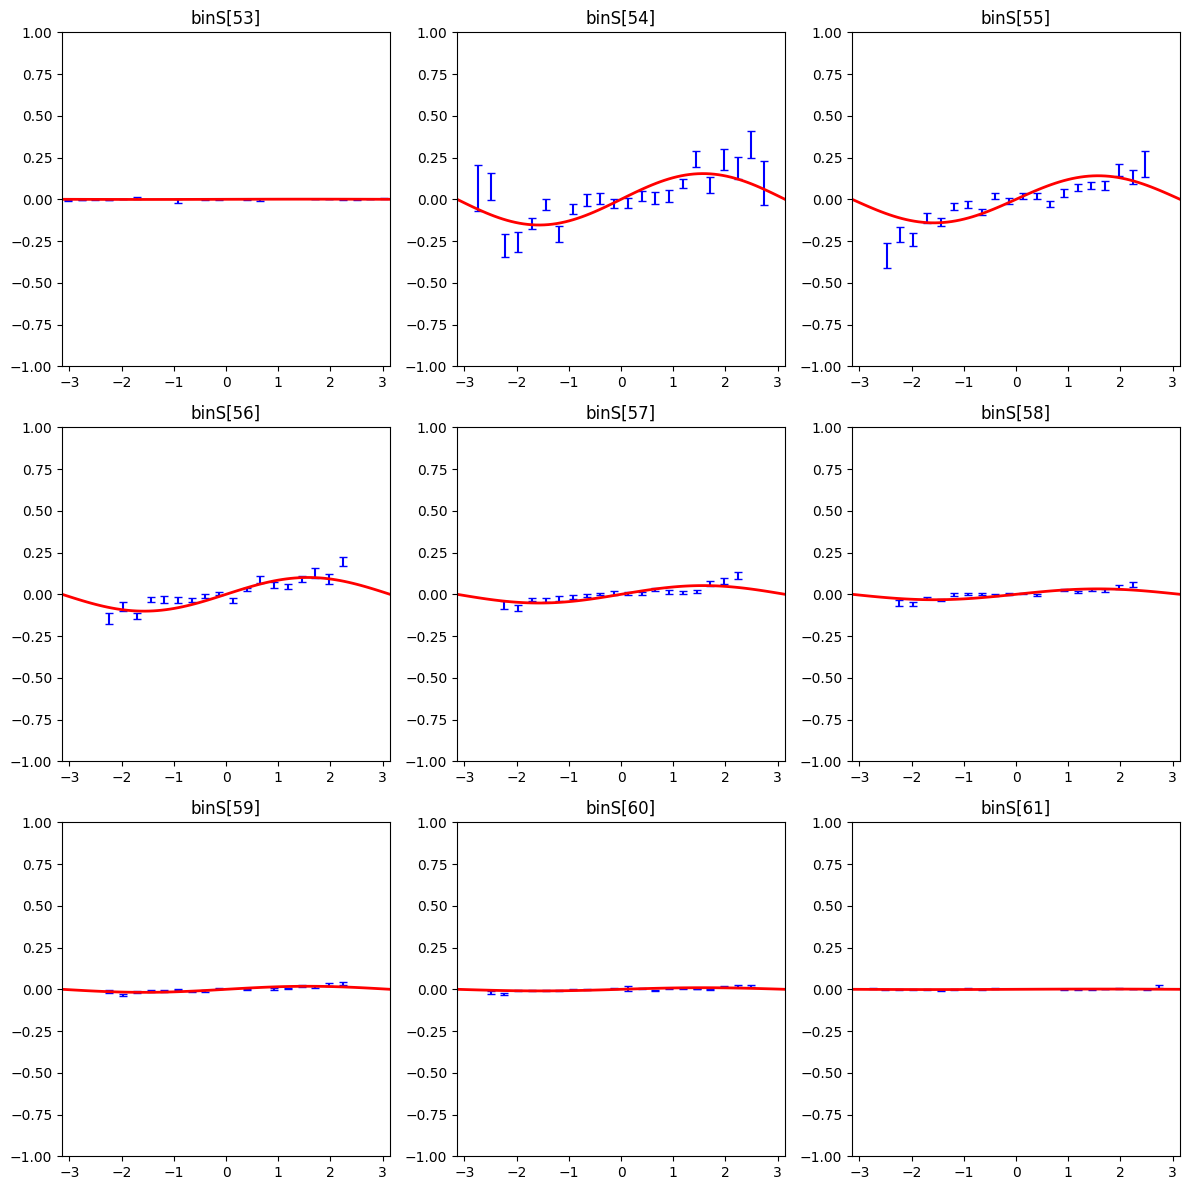

In [34]:
gridplot(53)

In [35]:
binS[27][['FTval', 'FTerr']].iloc[0]

FTval    0.355858
FTerr    0.023889
Name: 0, dtype: float64

In [36]:
clasfit(binS[27])

(0.2640843720025613, 0.023628731206944427)

# Possible pruning

In fits, one could consider removing data for which the value of the first sine FT harmonic is not statistically consistent with simple CLAS-like fit:

In [37]:
for k, bn in binS.items():
    s1, dels1 = clasfit(bn)
    mys1 = bn.FTval.iloc[0]
    mydels1 = bn.FTerr.iloc[0]
    nsigmas = abs(s1 - mys1)/mydels1
    if nsigmas > 1:
        print("bin {}: {:.3f}  {:.3f}, {:.1f} sigmas (row {})".format(k, mys1, dels1, nsigmas, k+63))

bin 1: 0.480  0.027, 2.6 sigmas (row 64)
bin 3: 0.212  0.014, 2.2 sigmas (row 66)
bin 4: 0.113  0.009, 3.0 sigmas (row 67)
bin 6: 0.015  0.002, 2.1 sigmas (row 69)
bin 9: 0.610  0.033, 4.6 sigmas (row 72)
bin 10: 0.340  0.021, 3.3 sigmas (row 73)
bin 11: 0.171  0.015, 2.8 sigmas (row 74)
bin 12: 0.134  0.010, 2.8 sigmas (row 75)
bin 13: 0.085  0.008, 2.4 sigmas (row 76)
bin 14: 0.034  0.004, 2.1 sigmas (row 77)
bin 15: 0.014  0.003, 1.6 sigmas (row 78)
bin 17: -0.000  633570616.365, 134586.3 sigmas (row 80)
bin 18: 0.431  0.034, 1.2 sigmas (row 81)
bin 20: 0.148  0.014, 1.1 sigmas (row 83)
bin 21: 0.170  0.010, 4.2 sigmas (row 84)
bin 22: 0.080  0.007, 1.9 sigmas (row 85)
bin 23: 0.033  0.004, 1.8 sigmas (row 86)
bin 24: 0.015  0.002, 1.3 sigmas (row 87)
bin 25: 0.003  0.001, 2.0 sigmas (row 88)
bin 27: 0.356  0.024, 3.8 sigmas (row 90)
bin 28: 0.193  0.013, 1.8 sigmas (row 91)
bin 29: 0.179  0.009, 5.6 sigmas (row 92)
bin 30: 0.085  0.006, 5.4 sigmas (row 93)
bin 31: 0.068  0.004, 5.4